<h1>Project Overview</h1>

This project focuses on analyzing customer purchase behavior to develop targeted marketing strategies. By implementing RFM (Recency, Frequency, Monetary) analysis, I segment the customer base into actionable groups, allowing for optimized retention efforts and revenue growth.

<h2>Business Tasks & Roadmap</h2>

1.Exploratory Data Analysis (EDA): Identifying global trends, top-performing countries, and seasonal sales dynamics.

2.Feature Engineering: Calculating key metrics (Recency, Frequency, Monetary) for every unique customer.

3.RFM Scoring: Applying the quantile method to score customers on a scale of 1 to 5.

4.Behavioral Segmentation: Categorizing customers into strategic segments (e.g., Champions, At Risk, Potential Loyalists).

5.Data Visualization: Creating an interactive map of the customer base to identify high-value opportunities and churn risks

##  Data Description

Before starting the analysis, it is essential to understand the structure of the dataset. The data consists of the following features:

| Column | Description |
| :--- | :--- |
| **InvoiceNo** | A unique 6-digit number assigned to each transaction. If it starts with 'C', it indicates a cancellation. |
| **StockCode** | Product (item) code. A unique 5-digit number assigned to each distinct product. |
| **Description** | Product (item) name. |
| **Quantity** | The number of units per transaction. |
| **InvoiceDate** | The date and time when the transaction was generated. |
| **UnitPrice** | Product price per unit in GBP (£). |
| **CustomerID** | A unique 5-digit number assigned to each customer. |
| **Country** | The name of the country where the customer resides. |

### Environment Setup & Libraries
We will use **Pandas** and **NumPy** for data manipulation, and **Matplotlib/Seaborn** for advanced data visualization.

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import  seaborn as sns


###  Data Loading & Initial Inspection
Loading the dataset and performing a quick check of the first few rows and data structures.

In [95]:
df = pd.read_csv('data.csv', encoding='ISO-8859-1')
df.columns = df.columns.str.strip() # Cleaning column names
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


###  Data Cleaning & Transformation

First, we need to ensure all features are in the correct format for analysis.

#### 1. DateTime Conversion
Converting `InvoiceDate` to a datetime object is essential for calculating **Recency**.

In [96]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'], format='mixed')
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  str           
 1   StockCode    541909 non-null  str           
 2   Description  540455 non-null  str           
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 33.1 MB


(541909, 8)

#### Note on Data Quality:

InvoiceDate is now successfully converted to datetime64.

We can see missing values in CustomerID and Description. These will need to be handled before calculating RFM scores.

### 2. Duplicate Values Handling
Duplicate rows can artificially inflate a customer's **Frequency** and **Monetary** scores, leading to incorrect RFM segmentation.

In this step, we:
* Identify the exact number of redundant transactions.
* Remove duplicates while keeping the first occurrence.
* Verify the final integrity of the dataset.

In [97]:
# Check total number of duplicate rows
print(f"Duplicates found: {df.duplicated().sum()}")

# Display sample of duplicate rows for verification
duplicates = df[df.duplicated(keep=False)].sort_values(by=list(df.columns))

# Remove duplicates and keep only the first occurrence
df = df.drop_duplicates(keep='first')

# Reset index to maintain continuous numbering
df = df.reset_index(drop=True)

# Verify final dataset dimensions
print(f"Dataset shape after cleaning: {df.shape}")

Duplicates found: 5268
Dataset shape after cleaning: (536641, 8)


### 3. Handling Missing Values
In this step, we address the missing values in the dataset. Our primary focus is the **CustomerID** column.

* **Reasoning:** Since RFM analysis is based on individual customer behavior, transactions without a unique `CustomerID` cannot be assigned to any segment.
* **Action:** We remove these records to ensure the integrity of our customer-level metrics.NAN

In [98]:
# Check the number of missing values before cleaning
print("Missing values per column:")
print(df.isnull().sum())

# Store the initial number of rows
rows_before = df.shape[0]

# Remove rows where CustomerID is null
df = df.dropna(subset=['CustomerID'])

# Reset index after removing rows
df = df.reset_index(drop=True)

# Calculate how many rows were removed
rows_after = df.shape[0]
print(f"\nRows removed: {rows_before - rows_after}")
print(f"Final dataset shape: {df.shape}")

Missing values per column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
dtype: int64

Rows removed: 135037
Final dataset shape: (401604, 8)


###  Handling Returns & Cancellations
In e-commerce datasets, transactions with negative **Quantity** or **UnitPrice** typically represent product returns or system errors.

* **Impact:** Including returns in RFM calculation can distort the *Monetary* value and lead to incorrect ranking.
* **Action:** We filter the dataset to include only successful transactions (Quantity > 0 and UnitPrice > 0).

In [99]:
# Filter out returns and cancellations to keep only successful sales
df = df.loc[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()

# Reset index again after filtering
df = df.reset_index(drop=True)

# Final verification of data types and non-null values
print(f"Dataset shape after removing returns: {df.shape}")
df.info()

Dataset shape after removing returns: (392692, 8)
<class 'pandas.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  str           
 1   StockCode    392692 non-null  str           
 2   Description  392692 non-null  str           
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[us]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 24.0 MB


#  Exploratory Data Analysis (EDA)

In this section, we analyze the general business metrics to identify sales patterns and geographical distribution of revenue.


###  Revenue Analysis by Geography
First, we calculate the total revenue for each transaction and identify the top-performing markets.

In [100]:
# Create Revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Group by country and calculate total revenue
countries_rank = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)

# Quick statistical overview of the Revenue column
print("Revenue Statistics:")
print(df['Revenue'].describe())

# Identify Top-5 countries by revenue
top_5_countries = countries_rank.head(5)
print("\nTop 5 Countries by Revenue:")
print(top_5_countries)

Revenue Statistics:
count    392692.000000
mean         22.631500
std         311.099224
min           0.001000
25%           4.950000
50%          12.450000
75%          19.800000
max      168469.600000
Name: Revenue, dtype: float64

Top 5 Countries by Revenue:
Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Name: Revenue, dtype: float64


###  Monthly Revenue Dynamics
To understand seasonal patterns and overall growth, we analyze the revenue distribution by month. This helps identify peak sales periods and potential seasonal trends.

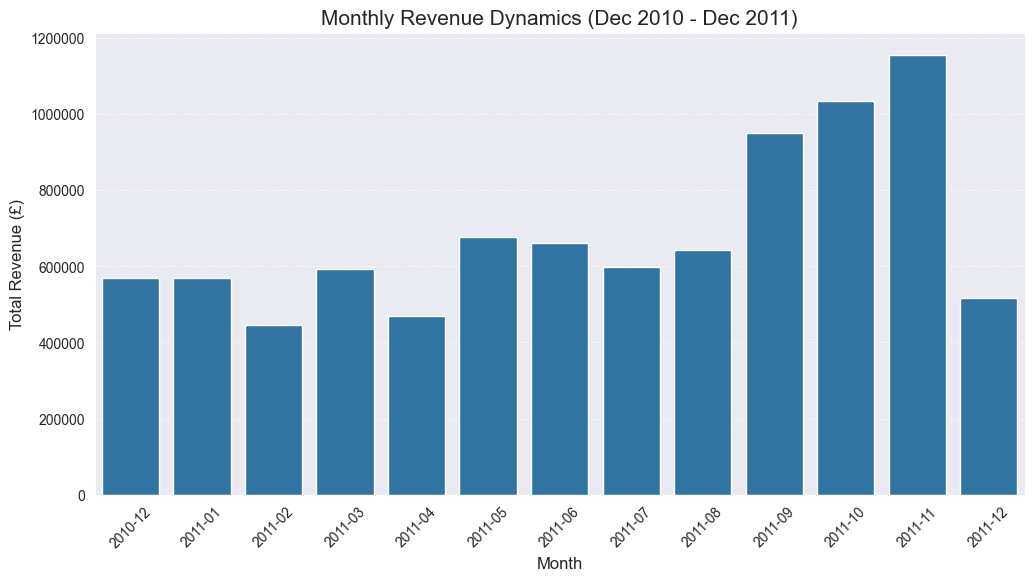

In [101]:
# Create year-month period for grouping
df['month_year'] = df['InvoiceDate'].dt.to_period('M')

# Calculate monthly revenue
monthly_revenue = df.groupby('month_year')['Revenue'].sum().reset_index()
monthly_revenue['month_year'] = monthly_revenue['month_year'].astype(str)

# Plotting the dynamics
plt.figure(figsize=(12, 6))
sns.barplot(data=monthly_revenue, x='month_year', y='Revenue')

# Professional formatting
plt.title('Monthly Revenue Dynamics (Dec 2010 - Dec 2011)', fontsize=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue (£)', fontsize=12)
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y') # Remove scientific notation (1e6)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

 We observe a massive sales peak in November 2011, likely due to holiday preparations (Black Friday/Christmas). The revenue in November is almost double that of the summer months.

###  Business Scale Overview
To understand the scope of the dataset, we calculate the total number of unique customers and distinct products sold during the period.

In [102]:
# Calculate unique identifiers for customers and products
unique_customers = df['CustomerID'].nunique()
unique_products = df['StockCode'].nunique()

print(f"Total Unique Customers: {unique_customers}")
print(f"Total Unique Products: {unique_products}")

Total Unique Customers: 4338
Total Unique Products: 3665


The dataset covers over 4.3k customers and 3.6k products, providing a solid foundation for robust behavioral segmentation.

#  RFM Metrics Calculation

To segment our customers, we need to calculate three key metrics for each unique **CustomerID**:

* **Recency (R):** Days since the last purchase. (Lower is better)
* **Frequency (F):** Total number of unique orders. (Higher is better)
* **Monetary (M):** Total revenue generated by the customer. (Higher is better)

**Reference Date:** We use the day after the last transaction in the dataset as the starting point for calculating Recency.
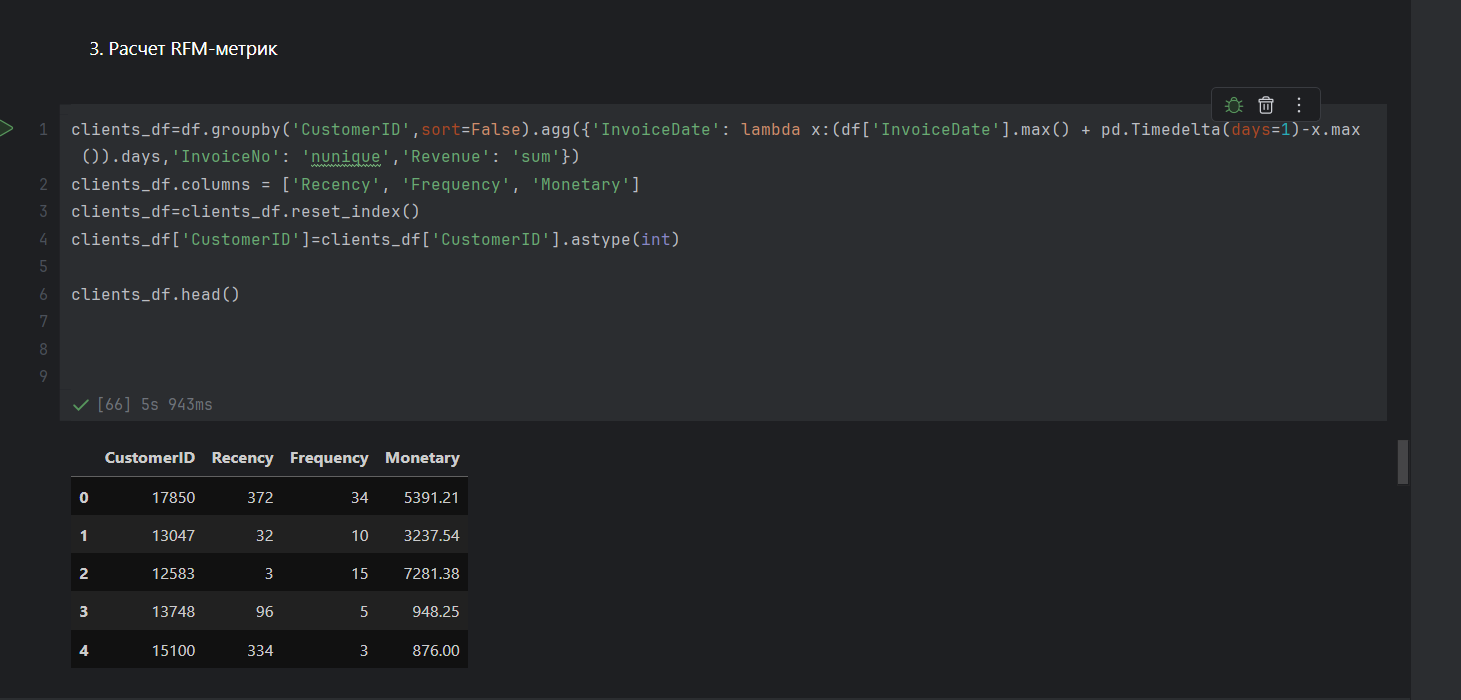

In [103]:
# Define the reference date (latest date in dataset + 1 day)
# This prevents a Recency of 0, which is better for statistical calculations
analysis_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Grouping by CustomerID and aggregating metrics
clients_df = df.groupby('CustomerID', sort=False).agg({
    # Recency: difference between analysis date and the latest purchase date
    'InvoiceDate': lambda x: (analysis_date - x.max()).days,

    # Frequency: count of unique Invoice numbers
    'InvoiceNo': 'nunique',

    # Monetary: total sum of all transactions
    'Revenue': 'sum'
})

# Rename columns to standard RFM terminology
clients_df.columns = ['Recency', 'Frequency', 'Monetary']

# Reset index to make CustomerID a regular column and convert it to integer
clients_df = clients_df.reset_index()
clients_df['CustomerID'] = clients_df['CustomerID'].astype(int)

# Preview the calculated RFM profiles
clients_df.head()

,CustomerID,Recency,Frequency,Monetary
0,17850,372,34,5391.21
1,13047,32,10,3237.54
2,12583,3,15,7281.38
3,13748,96,5,948.25
4,15100,334,3,876.00


The clients_df table now represents a unique profile for each customer.

## 5. RFM Scoring

We use the **Quantile Method** to assign scores from 1 to 5 for each metric. This ensures an even distribution of customers across segments.

* **Recency Score:** 5 is assigned to the most recent customers (lowest Recency value).
* **Frequency Score:** 5 is assigned to the most frequent buyers.
* **Monetary Score:** 5 is assigned to the highest spenders.

**Total Score:** A combined metric calculated as the sum of R, F, and M scores (ranging from 3 to 15).

In [104]:
# 1. Assign scores from 1 to 5 using quantiles
# For Recency, lower values get higher scores (5, 4, 3, 2, 1)
clients_df['R_Score'] = pd.qcut(clients_df['Recency'], q=5, labels=[5, 4, 3, 2, 1])

# For Frequency and Monetary, higher values get higher scores (1, 2, 3, 4, 5)
# Using .rank(method='first') for Frequency to handle non-unique bin edges
clients_df['F_Score'] = pd.qcut(clients_df['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
clients_df['M_Score'] = pd.qcut(clients_df['Monetary'], q=5, labels=[1, 2, 3, 4, 5])

# 2. Convert scores to integers for calculation
clients_df['R_Score'] = clients_df['R_Score'].astype(int)
clients_df['F_Score'] = clients_df['F_Score'].astype(int)
clients_df['M_Score'] = clients_df['M_Score'].astype(int)

# 3. Calculate the Total RFM Score
clients_df['Total_Score'] = clients_df['R_Score'] + clients_df['F_Score'] + clients_df['M_Score']

# Preview the scored dataset
clients_df.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,Total_Score
0,17850,372,34,5391.21,1,5,5,11
1,13047,32,10,3237.54,4,5,5,14
2,12583,3,15,7281.38,5,5,5,15
3,13748,96,5,948.25,2,4,4,10
4,15100,334,3,876.00,1,3,3,7


##  Customer Segmentation

Now we categorize customers into strategic segments based on their RFM scores to develop targeted marketing actions:

| Segment | Logic | Marketing Strategy |
| :--- | :--- | :--- |
| **Champions** | High R, High F, High M | Reward them. Early access to new products. |
| **Potential Loyalists** | Recent customers with good frequency | Upsell, offer loyalty programs. |
| **At Risk** | Haven't bought in a while, but were frequent | Personalized re-activation emails. |
| **Can't Lose Them** | Top spenders who haven't returned | Aggressive discounts and direct outreach. |
| **Normal/Others** | Everyone else | Standard newsletters. |

Status
Normal/Others          1968
Champions               978
Potential Loyalists     794
At Risk                 565
Can't Lose Them          33
Name: count, dtype: int64


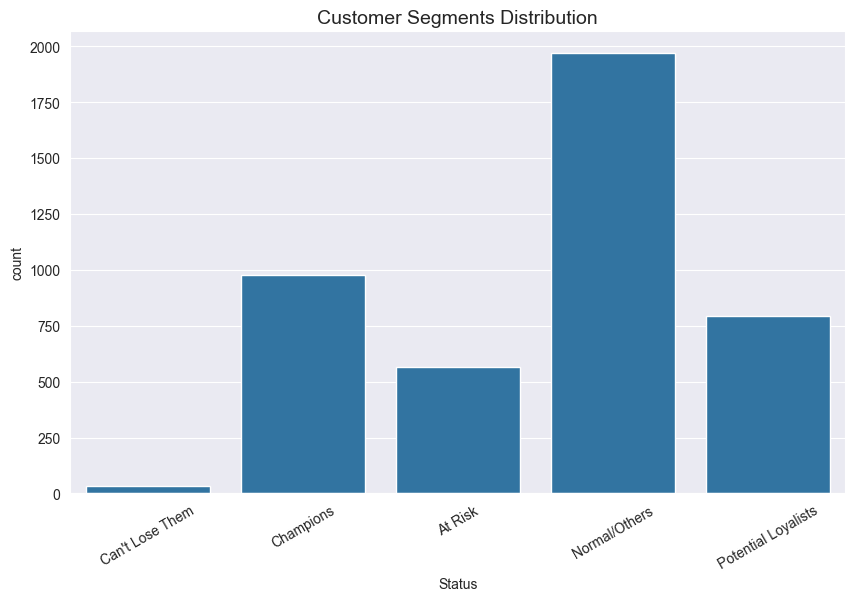

In [105]:
# 1. Initialize all customers with a default status
clients_df['Status'] = 'Normal/Others'

# 2. Identify 'At Risk' segment (Broad group)
clients_df.loc[(clients_df['R_Score'] <= 2) & (clients_df['F_Score'] >= 3), 'Status'] = 'At Risk'

# 3. Identify 'Potential Loyalists' (High potential for growth)
clients_df.loc[(clients_df['R_Score'] >= 4) & (clients_df['F_Score'] >= 2), 'Status'] = 'Potential Loyalists'

# 4. IMPORTANT: Identify 'Can't Lose Them' segment (High-value customers at risk)
clients_df.loc[(clients_df['R_Score'] <= 2) & (clients_df['F_Score'] == 5) & (clients_df['M_Score'] == 5), 'Status'] = "Can't Lose Them"

# 5. PRIORITY: Identify 'Champions' (Best customers)
clients_df.loc[(clients_df['R_Score'] >= 4) & (clients_df['F_Score'] >= 4) & (clients_df['M_Score'] >= 4), 'Status'] = 'Champions'

# Display segment distribution
print(clients_df['Status'].value_counts())

# Visualization of segments
plt.figure(figsize=(10, 6))
plt.xticks(rotation=30, fontsize=10)
sns.countplot(data=clients_df, x='Status')
plt.title('Customer Segments Distribution', fontsize=14)
plt.show()

график, показывающий связь между частотой покупок и потраченными деньгами

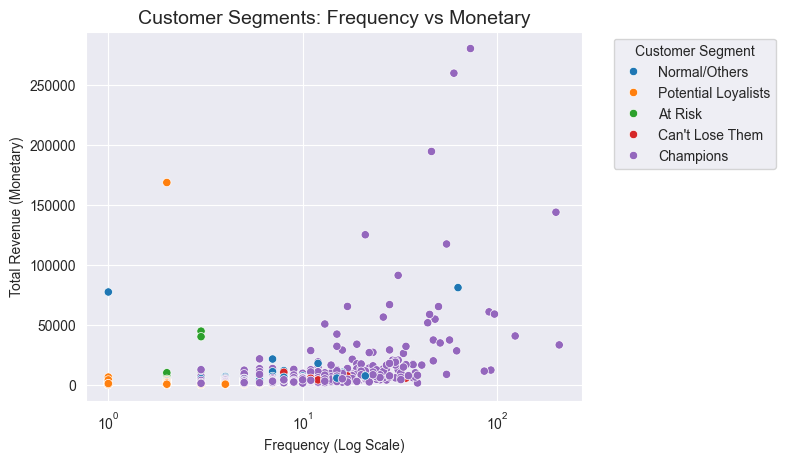

In [106]:
# Create a scatter plot to visualize the relationship between Frequency and Monetary value
# Using a log scale for the X-axis (Frequency) to handle high-variance data
sns.scatterplot(data=clients_df, x='Frequency', y='Monetary', hue='Status',
                hue_order=['Normal/Others', 'Potential Loyalists', 'At Risk', "Can't Lose Them", 'Champions'])

plt.xscale('log') # Logarithmic scale helps visualize clusters more clearly
plt.title('Customer Segments: Frequency vs Monetary', fontsize=14)
plt.xlabel('Frequency (Log Scale)')
plt.ylabel('Total Revenue (Monetary)')
plt.legend(title='Customer Segment', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

#  Final Conclusion: Customer Behavior & RFM Segmentation

In this project, we performed a comprehensive analysis of e-commerce transactional data. The study involved deep data cleaning, exploratory analysis, and advanced customer segmentation.

### 1. Data Cleaning & Preparation
* **Noise Reduction:** We removed approximately **135,000 records** lacking a `CustomerID`, as unique identification is essential for behavioral analysis.
* **Data Hygiene:** Over **5,000 duplicate rows** were eliminated, and transactions with negative `Quantity` or `UnitPrice` (returns/errors) were filtered out to prevent skewing the **Monetary** metrics.
* **Precision:** The dataset was refined from 541k raw rows down to **392,692 validated transactions**, ensuring high-quality input for the RFM model.

### 2. Exploratory Data Analysis (EDA) Insights
* **Geographical Performance:** The **United Kingdom** is the dominant market (~£7.28M revenue). Other key markets include the Netherlands, EIRE, Germany, and France.
* **Seasonality:** A major revenue spike was observed in **November 2011** (£1.15M), likely driven by holiday shopping trends.
* **Business Scale:** The final processed dataset represents **4,338 unique customers** and **3,665 unique products**.

### 3. RFM Segmentation Results
Customers were categorized into five strategic segments based on their **Recency**, **Frequency**, and **Monetary** scores:

| Segment | Count | Description |
| :--- | :--- | :--- |
| **Champions** | 978 | Our best customers: they buy often, recently, and spend the most. |
| **Potential Loyalists** | 794 | Recent customers with good average frequency and spend. |
| **At Risk** | 565 | Customers who were frequent in the past but haven't returned recently. |
| **Can't Lose Them** | 33 | High-value VIP customers who have stopped purchasing. Critical for recovery. |
| **Normal/Others** | 1,968 | Casual or one-time shoppers with low engagement. |

###  Business Recommendations
* **Retention:** Implement a VIP loyalty program for **Champions** to maintain their high LTV (Lifetime Value).
* **Nurturing:** Target **Potential Loyalists** with personalized product recommendations to increase their purchase frequency.
* **Re-activation:** Launch urgent win-back campaigns for the **"Can't Lose Them"** segment using high-value discount codes or direct outreach.
* **Planning:** Marketing budgets should be scaled up 2 months prior to the **November peak** to capitalize on the confirmed seasonal trend.